# Timing SMARCB1 deletion (CN-LOH) and clonal expansion

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pybedtools
import warnings; warnings.simplefilter('ignore')
import numpy as np
from numpy.polynomial.polynomial import polyfit
from scipy import stats

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def annot_cn_major_minor (row,cn_ranges_list):
    nminor = None
    nmajor = None
    pos = row['POS']
    for cn_range in cn_ranges_list:
        start = cn_range['startpos']
        end = cn_range['endpos']
        if int(pos) > int(start) and int(pos) < int(end):
            nminor = cn_range['nMinor']
            nmajor = cn_range['nMajor']
            break
        else:
            pass

    row['nMajor'] = nmajor
    row['nMinor'] = nminor

    return row

def mut_per_CN_tables (samples_dict,path_to_ascat,path_to_mafs,purity_dict=None,mappgen=True,min_depth=80):

    final_df = pd.DataFrame({'n_copies':[1,2]})
    final_per_mb_df = pd.DataFrame({'n_copies':[1,2]})
    chunk_size_dict = {}

    for pt in samples_dict.keys():
        for tumor in [t for t in samples_dict[pt].keys() if 'tumor' in t]:
            print('\n',pt,tumor)
            tumor_id = samples_dict[pt][tumor]
            normal_id = samples_dict[pt]['normal']
            sample_id = tumor_id + '_vs_' + normal_id
            if pt in ['pt15','PARIRN']:
                chrom = '19'
            else:
                chrom = '22'

            #CN
            df = pd.read_csv(path_to_ascat+sample_id+'/'+sample_id+'.segments.txt',sep='\t')
            df['chr'] = df['chr'].astype(str)
            chr_cn_df = df[df['chr']==chrom]
            # xmin = chr_cn_df['startpos'].tolist()
            # xmax = chr_cn_df['endpos'].tolist()
            
            #correct CN in the samples with wrong WGD:
            if pt+'_'+tumor in ['pt5_tumor2','SJ030581_tumor1','PASVDP_tumor1']:
                for col in ['nMajor','nMinor']:
                    chr_cn_df[col] = chr_cn_df[col].apply(lambda x: int(x-1) if x!=0 else x)

            cn_ranges_list = chr_cn_df[['startpos','endpos','nMajor','nMinor']].to_dict(orient='records')

            #VAF corrected by purity
            path = path_to_mafs+pt+'/'+sample_id+'/filter_and_annot/'+sample_id+'_filt.maf.gz'
            df = pd.read_csv(path,sep='\t')
            if purity_dict != None:
                purity = purity_dict[pt+'_t'+tumor[-1]]
            else:
                purity = df['purity'][0]
            df['#CHROM'] = df['#CHROM'].astype(str)
            chr_df = df[(df['#CHROM']=='chr'+chrom)]
            chr_df['t_AF_corrected'] = chr_df['t_AF'].apply(lambda x: x/purity)
            
            #filter mut_type == 'snv'
            chr_df = chr_df[chr_df['mut_type']=='snv']
            print(len(chr_df),'total snv mutations')
            #filter gnomAF <0.001
            chr_df = chr_df[chr_df['gnomADg_AF']<0.001]
            print(len(chr_df),'mutations after gnomad <0.001 filter')
            #filter by depth
            chr_df = chr_df[chr_df['DP_tumor']>min_depth]
            print(len(chr_df),'mutations after DP >'+str(min_depth)+' filter')
            
            if len(chr_df) != 0:
                if mappgen == True:

                    #filter out mutations from low mappability regions with pybedtools intersect with the mappable genome
                    mapp_genome_df = pd.read_csv('mappable_genome/hg38_100bp.coverage.regions.filtered_blacklisted.gz',sep='\t')
                    chr_mapp_genome_df = mapp_genome_df[mapp_genome_df['CHR']=='chr'+chrom]

                    chr_copy_df = chr_df.copy()
                    chr_copy_df['POS2'] = chr_df['POS'] + 1
                    chr_copy_df = chr_copy_df[['#CHROM','POS','POS2','REF','ALT','FILTER']]
                    mappgen_bt = pybedtools.BedTool.from_dataframe(chr_mapp_genome_df)
                    snvs_bt = pybedtools.BedTool.from_dataframe(chr_copy_df)
                    mappgen_and_snvs = snvs_bt.intersect(mappgen_bt)
                    chr_mappgen_df = mappgen_and_snvs.to_dataframe()
                    if len(chr_mappgen_df) == 0:
                        chr_mappgen_df = pd.DataFrame(columns=['#CHROM','POS','REF','ALT','FILTER','nMajor','nMinor'])
                    else:
                        chr_mappgen_df = chr_mappgen_df.rename(columns={'chrom':'#CHROM','start':'POS','end':'POS2',
                                                                         'name':'REF','score':'ALT','strand':'FILTER'})
                        chr_mappgen_df = chr_mappgen_df.drop(columns=['POS2'])

                    chr_df = pd.merge(chr_mappgen_df,chr_df,how='left')
                    print(len(chr_copy_df), len(chr_df), 'before - after filtering for mappable genome')

                chr_df = chr_df.apply(lambda row: annot_cn_major_minor(row,cn_ranges_list),axis=1)

                cn_loh_df = chr_df[(chr_df['nMajor']==2)&(chr_df['nMinor']==0)&(chr_df['clonal']==True)]
                print(len(cn_loh_df),'Any mutations in CN-LOH?')
                
                if len(cn_loh_df) != 0:
                    cn_loh_df['n_copies'] = cn_loh_df['t_AF_corrected'].apply(lambda x: 1 if x <0.75 else 2)
                    count_muts_df = cn_loh_df[['n_copies','mut']].groupby('n_copies',as_index=False).count()
                    count_muts_df.rename(columns={'mut':pt+'_t'+tumor[-1]},inplace=True)
                    final_df = pd.merge(final_df,count_muts_df,on='n_copies',how='outer')

                    #calculate size of the chunk with the CN LOH
                    cnloh_chunk_size = 0
                    for cn_range in cn_ranges_list:
                        if cn_range['nMajor'] == 2 and cn_range['nMinor'] == 0:
                            chunk_size = cn_range['endpos'] - cn_range['startpos']
                            cnloh_chunk_size = cnloh_chunk_size + chunk_size
                    if cnloh_chunk_size > 10000000: # set a minimum of 10Mb of chunk size in CNLOH
                        count_per_mb_df = count_muts_df.copy()
                        count_per_mb_df[pt+'_t'+tumor[-1]] = count_per_mb_df[pt+'_t'+tumor[-1]] / (cnloh_chunk_size/1000000)
                        chunk_size_dict[pt+'_t'+tumor[-1]] = cnloh_chunk_size
                        final_per_mb_df = pd.merge(final_per_mb_df,count_per_mb_df,on='n_copies',how='outer')

    final_df.fillna(0,inplace=True)
    final_df.index = final_df['n_copies']
    final_df.drop(['n_copies'],inplace=True,axis=True)

    final_per_mb_df.fillna(0,inplace=True)
    final_per_mb_df.index = final_per_mb_df['n_copies']
    final_per_mb_df.drop(['n_copies'],inplace=True,axis=True)
    return final_df, final_per_mb_df, chunk_size_dict

## Load sample dictionaries

In [3]:
sjd_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
tumors_dict = {'tumor1':'t1','tumor2':'t2'}

target_dict = json.load(open('sample_ids/sample_target_ids.json','rb'))
target_dict = {pt:target_dict[pt] for pt in target_dict.keys() if 'normal' in target_dict[pt].keys()}

stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))

pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))

samples_dict = sjd_dict | target_dict | stjude_dict | pmc_dict
pts = samples_dict.keys()

In [4]:
samples2_dict = {samples_dict[pt][tumor]:tumor for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor != 'sex'}
samples_list = [pt+'_t'+tumor[-1] for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor not in ['normal','normal2','sex','clone1','clone2']]
samples_list = [pt if pt.startswith('pt') | pt.startswith('PMC') else pt.split('_t')[0] for pt in samples_list]
print(samples_list)

['pt1_t1', 'pt1_t2', 'pt3_t1', 'pt3_t2', 'pt4_t1', 'pt4_t2', 'pt5_t1', 'pt5_t2', 'pt6_t1', 'pt6_t2', 'pt7_t1', 'pt8_t1', 'pt9_t1', 'pt9_t2', 'pt11_t1', 'pt12_t1', 'pt12_t2', 'pt13_t1', 'pt14_t1', 'pt14_t2', 'pt15_t1', 'pt16_t1', 'pt17_t1', 'pt18_t1', 'pt18_t2', 'pt19_t1', 'pt20_t1', 'PABKLN', 'PADWRZ', 'PADYZI', 'PAEHIP', 'PAJLWM', 'PAJMBW', 'PAJMRB', 'PAJNER', 'PAJNFP', 'PAJNFZ', 'PAKHTL', 'PAKLYZ', 'PAKTCT', 'PARECB', 'PAREWI', 'PARGRN', 'PARIRN', 'PARPFY', 'PARRCL', 'PARTKH', 'PARUGK', 'PARZBI', 'PARZRH', 'PASABD', 'PASADZ', 'PASCDH', 'PASDLA', 'PASGCL', 'PASRHU', 'PASVDP', 'PASWZZ', 'PASXNA', 'PASYNF', 'PASZYE', 'PATAFT', 'PATBLF', 'PATDVL', 'PATENH', 'PATFXW', 'PATFZZ', 'PATXEE', 'PATXKA', 'PAUCGJ', 'PAUDPV', 'PAUEKW', 'PAUFVP', 'PAUGYZ', 'PAUHAZ', 'PAUNPA', 'PAVCKS', 'PAVITI', 'PAVYDM', 'PAVYKD', 'PAWDGA', 'PAWFBL', 'PAWFWK', 'SJ014754', 'SJ015723', 'SJ030128', 'SJ030255', 'SJ030581', 'SJ030707', 'SJ030896', 'SJ030997', 'SJ031235', 'SJ031605', 'SJ031948', 'SJ032047', 'SJ032346', 

In [5]:
purity_sjd_dict = json.load(open('purities/purities_sjd.json','rb'))
purity_target_dict = json.load(open('purities/purities_target.json','rb'))
purity_stjude_dict = json.load(open('purities/purities_stjude.json','rb'))
purity_pmc_dict = json.load(open('purities/purities_pmc_case.json','rb'))
purity_dict = purity_sjd_dict | purity_target_dict | purity_stjude_dict | purity_pmc_dict

In [6]:
low_purity_samples = [ sample for sample in purity_dict.keys() if purity_dict[sample]<0.5]

In [7]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

## Create tables for each cohort

In [8]:
#SJD cohort
path_to_ascat = 'variant_calling/sjd_cohort/sarek_results/variant_calling/ascat/'
path_to_mafs = 'mafs/mafs_sjd/'
sjd_map_df, sjd_map_per_mb_df, sjd_chunk_map_size_dict = mut_per_CN_tables (samples_dict=sjd_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=purity_dict,mappgen=True)
sjd_wg_df, sjd_wg_per_mb_df, sjd_chunk_wg_size_dict = mut_per_CN_tables (samples_dict=sjd_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=purity_dict,mappgen=False)

# TARGET cohort
path_to_ascat = 'variant_calling/target_cohort/sarek_results/variant_calling/ascat/'
path_to_mafs = 'mafs/mafs_target/'
target_map_df, target_map_per_mb_df, target_chunk_map_size_dict = mut_per_CN_tables (samples_dict=target_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=None,mappgen=True,min_depth=20)
target_wg_df, target_wg_per_mb_df, target_chunk_wg_size_dict = mut_per_CN_tables (samples_dict=target_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=None,mappgen=False,min_depth=20)

# St Jude cohort
path_to_ascat = 'variant_calling/stjude_cohort/sarek_results/variant_calling/ascat/'
path_to_mafs = 'mafs/mafs_stjude/'
stjude_map_df, stjude_map_per_mb_df, stjude_chunk_map_size_dict = mut_per_CN_tables (samples_dict=stjude_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=None,mappgen=True,min_depth=20)
stjude_wg_df, stjude_wg_per_mb_df, stjude_chunk_wg_size_dict = mut_per_CN_tables (samples_dict=stjude_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=None,mappgen=False,min_depth=20)

# PMC case
path_to_ascat = 'variant_calling/pmc_case/sarek_results/variant_calling/ascat/'
path_to_mafs = 'mafs/mafs_pmc/'
pmc_map_df, pmc_map_per_mb_df, pmc_chunk_map_size_dict = mut_per_CN_tables (samples_dict=pmc_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=None,mappgen=True,min_depth=15)
pmc_wg_df, pmc_wg_per_mb_df, pmc_chunk_wg_size_dict = mut_per_CN_tables (samples_dict=pmc_dict,path_to_ascat=path_to_ascat,path_to_mafs=path_to_mafs,
                  purity_dict=None,mappgen=False,min_depth=15)


 pt1 tumor1
33 total snv mutations
24 mutations after gnomad <0.001 filter
22 mutations after DP >80 filter
22 13 before - after filtering for mappable genome
0 Any mutations in CN-LOH?

 pt1 tumor2
21 total snv mutations
19 mutations after gnomad <0.001 filter
18 mutations after DP >80 filter
18 14 before - after filtering for mappable genome
0 Any mutations in CN-LOH?

 pt3 tumor1
27 total snv mutations
10 mutations after gnomad <0.001 filter
9 mutations after DP >80 filter
9 9 before - after filtering for mappable genome
0 Any mutations in CN-LOH?

 pt3 tumor2
52 total snv mutations
42 mutations after gnomad <0.001 filter
41 mutations after DP >80 filter
41 33 before - after filtering for mappable genome
0 Any mutations in CN-LOH?

 pt4 tumor1
27 total snv mutations
10 mutations after gnomad <0.001 filter
6 mutations after DP >80 filter
6 5 before - after filtering for mappable genome
0 Any mutations in CN-LOH?

 pt4 tumor2
8 total snv mutations
2 mutations after gnomad <0.001 filt

In [9]:
sjd_wg_df

,pt6_t1,pt6_t2,pt7_t1,pt8_t1,pt15_t1
n_copies,,,,,
1,8.0,8.0,39.0,4,18.0
2,0.0,0.0,0.0,1,0.0


In [10]:
pmc_wg_df

,PMC01_t1,PMC01_t2,PMC01_t3,PMC01_t4
n_copies,,,,
1,8.0,4.0,2.0,5.0
2,0.0,0.0,0.0,0.0


In [11]:
sjd_map_per_mb_df

,pt6_t1,pt6_t2,pt7_t1,pt8_t1,pt15_t1
n_copies,,,,,
1,0.23115,0.231929,1.370331,0.113555,0.977451
2,0.00000,0.000000,0.000000,0.028389,0.000000


In [12]:
pmc_map_per_mb_df

,PMC01_t1,PMC01_t2,PMC01_t3,PMC01_t4
n_copies,,,,
1,0.213283,0.08512,0.028373,0.121876
2,0.000000,0.00000,0.000000,0.000000


In [13]:
sjd_chunk_wg_size_dict

{'pt6_t1': 30283385,
 'pt6_t2': 30181611,
 'pt7_t1': 27000780,
 'pt8_t1': 35225172,
 'pt15_t1': 15346036}

In [14]:
stjude_map_per_mb_df

,SJ030997_t1,SJ031235_t1,SJ031948_t1,SJ032346_t1
n_copies,,,,
1,0.088068,0.032763,1.572623,0.296997
2,0.000000,0.000000,0.000000,0.000000


In [15]:
stjude_chunk_wg_size_dict

{'SJ030997_t1': 34064713,
 'SJ031235_t1': 30522234,
 'SJ031948_t1': 26706970,
 'SJ032346_t1': 26936257}

## Load age dictionaries

In [16]:
tab_dict = json.load(open('clinical_data/tab_dict.json','rb'))
tab_dict

{'pt1_t1': 8.32,
 'pt1_t2': 8.56,
 'pt3_t1': 4.79,
 'pt3_t2': 6.16,
 'pt4_t1': 0.02,
 'pt4_t2': 0.03,
 'pt5_t1': 13.5,
 'pt5_t2': 13.7,
 'pt6_t1': 1.6,
 'pt6_t2': 1.64,
 'pt7_t1': 2.25,
 'pt8_t1': 3.02,
 'pt9_t1': 0.44,
 'pt9_t2': 0.49,
 'pt11_t1': 5.57,
 'pt12_t1': 0.68,
 'pt12_t2': 0.68,
 'pt13_t1': 0.53,
 'pt14_t1': 10.1,
 'pt14_t2': 10.5,
 'pt15_t1': 15.58,
 'pt16_t1': 1.67,
 'pt17_t1': 2.61,
 'pt18_t1': 0.01,
 'pt18_t2': 0.02,
 'pt19_t1': 1.13,
 'pt20_t1': 0.57,
 'PABKLN': 1.1,
 'PADWRZ': 1.05,
 'PADYCE': 2.28,
 'PADYZI': 2.97,
 'PAEHIP': 0.48,
 'PAJLRA': 0.01,
 'PAJLWM': 0.79,
 'PAJMBW': 0.39,
 'PAJMRB': 1.48,
 'PAJNER': 0.17,
 'PAJNFP': 0.96,
 'PAJNFZ': 1.62,
 'PAJPHJ': 0.95,
 'PAKHTL': 3.13,
 'PAKLYZ': 1.44,
 'PAKPEW': 2.6,
 'PAKTCT': 2.36,
 'PARECB': 0.38,
 'PAREWI': 0.84,
 'PARGRN': 0.4,
 'PARIRN': 4.02,
 'PARKKN': 6.45,
 'PARPFY': 0.99,
 'PARRCL': 0.59,
 'PARTKH': 0.73,
 'PARUGK': 0.6,
 'PARZBI': 1.44,
 'PARZRH': 1.67,
 'PASABD': 0.47,
 'PASADZ': 0.75,
 'PASAMZ': 8.29,
 'PAS

## Merge all tables

In [17]:
df1 = target_wg_per_mb_df.T[[2,1]]
df1['patient'] = df1.index
df1['patient'] = df1['patient'].str.split('_',expand=True)[0]
df1.set_index('patient',inplace=True)
df2 = sjd_wg_per_mb_df.T[[2,1]]
df3 = stjude_wg_per_mb_df.T[[2,1]]
df3['patient'] = df3.index
df3['patient'] = df3['patient'].str.split('_',expand=True)[0]
df3.set_index('patient',inplace=True)
df4 = pmc_wg_per_mb_df.T[[2,1]]
wg_per_mb_df = pd.concat([df1,df2,df3,df4])
wg_per_mb_df['age'] = wg_per_mb_df.index.map(tab_dict)
wg_per_mb_df = wg_per_mb_df.sort_values('age',ascending=True)

In [18]:
df1 = target_map_per_mb_df.T[[2,1]]
df1['patient'] = df1.index
df1['patient'] = df1['patient'].str.split('_',expand=True)[0]
df1.set_index('patient',inplace=True)
df2 = sjd_map_per_mb_df.T[[2,1]]
df3 = stjude_map_per_mb_df.T[[2,1]]
df3['patient'] = df3.index
df3['patient'] = df3['patient'].str.split('_',expand=True)[0]
df3.set_index('patient',inplace=True)
df4 = pmc_map_per_mb_df.T[[2,1]]
map_per_mb_df = pd.concat([df1,df2,df3,df4])
map_per_mb_df['age'] = map_per_mb_df.index.map(tab_dict)
map_per_mb_df = map_per_mb_df.sort_values('age',ascending=True)

In [19]:
df1 = target_map_df.T[[2,1]]
df1['patient'] = df1.index
df1['patient'] = df1['patient'].str.split('_',expand=True)[0]
df1.set_index('patient',inplace=True)
df2 = sjd_map_df.T[[2,1]]
df3 = stjude_map_df.T[[2,1]]
df3['patient'] = df3.index
df3['patient'] = df3['patient'].str.split('_',expand=True)[0]
df3.set_index('patient',inplace=True)
df4 = pmc_map_df.T[[2,1]]
map_df = pd.concat([df1,df2,df3,df4])
map_df['age'] = map_df.index.map(tab_dict)
map_df = map_df.sort_values('age',ascending=True)

In [20]:
df1 = target_wg_df.T[[2,1]]
df1['patient'] = df1.index
df1['patient'] = df1['patient'].str.split('_',expand=True)[0]
df1.set_index('patient',inplace=True)
df2 = sjd_wg_df.T[[2,1]]
df3 = stjude_wg_df.T[[2,1]]
df3['patient'] = df3.index
df3['patient'] = df3['patient'].str.split('_',expand=True)[0]
df3.set_index('patient',inplace=True)
df4 = pmc_wg_df.T[[2,1]]
wg_df = pd.concat([df1,df2,df3,df4])
wg_df['age'] = wg_df.index.map(tab_dict)
wg_df = wg_df.sort_values('age',ascending=True)

In [21]:
wg_per_mb_df

n_copies,2,1,age
PAUDPV,0.000000,0.028373,0.15
PAJNER,0.073822,0.000000,0.17
PAVYKD,0.028865,0.086595,0.18
PASWZZ,0.000000,0.101171,0.18
PARECB,0.000000,0.028373,0.38
PAEHIP,0.028479,0.028479,0.48
SJ030997,0.000000,0.117424,0.50
PASYNF,0.000000,0.032673,0.56
PARUGK,0.028373,0.085120,0.60
PAWFWK,0.101912,0.203824,0.63


In [22]:
chunk_map_size_dict = sjd_chunk_map_size_dict | target_chunk_map_size_dict | stjude_chunk_map_size_dict | pmc_chunk_map_size_dict

In [23]:
with open('data/chunk_map_size_dict', 'w') as f:
    json.dump(chunk_map_size_dict,f)

In [24]:
df1

n_copies,2,1
patient,,
PADWRZ,1.0,8.0
PAEHIP,1.0,1.0
PAJLWM,0.0,2.0
PAJMRB,1.0,2.0
PAJNER,2.0,0.0
PAJNFP,1.0,2.0
PAJNFZ,0.0,2.0
PARECB,0.0,1.0
PAREWI,0.0,1.0


## Plots

In [25]:
low_purity_samples

['pt7_t1',
 'pt12_t1',
 'pt14_t1',
 'pt14_t2',
 'pt16_t1',
 'pt20_t1',
 'PAJNER',
 'SJ030896',
 'HK']

In [26]:
map_per_mb_df

n_copies,2,1,age
PAUDPV,0.000000,0.028373,0.15
PAJNER,0.073822,0.000000,0.17
PAVYKD,0.028865,0.086595,0.18
PASWZZ,0.000000,0.101171,0.18
PAEHIP,0.028479,0.028479,0.48
SJ030997,0.000000,0.088068,0.50
PASYNF,0.000000,0.032673,0.56
PARUGK,0.028373,0.056747,0.60
PAWFWK,0.067941,0.203824,0.63
SJ031235,0.000000,0.032763,0.67


In [27]:
low_purity_samples

['pt7_t1',
 'pt12_t1',
 'pt14_t1',
 'pt14_t2',
 'pt16_t1',
 'pt20_t1',
 'PAJNER',
 'SJ030896',
 'HK']

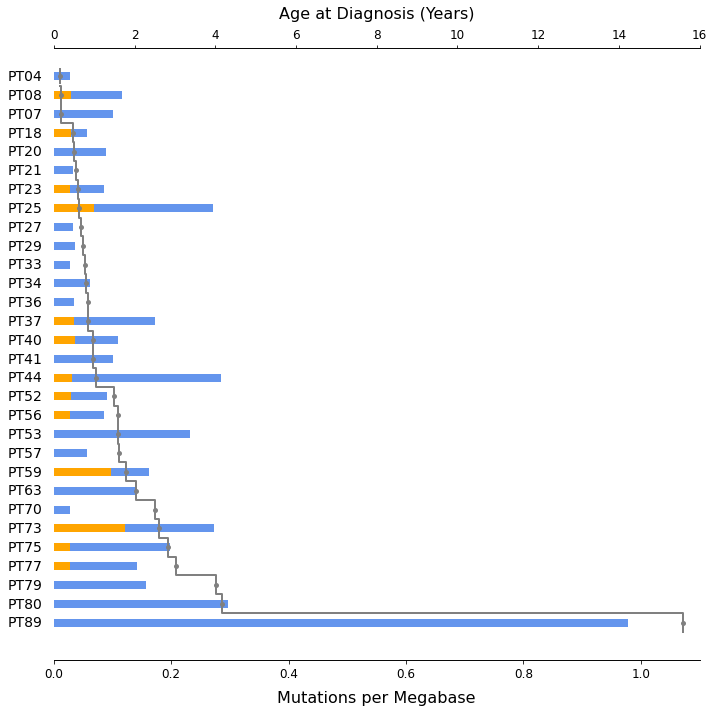

In [28]:
import matplotlib.pyplot as plt

df1 = map_per_mb_df.copy()
def get_pt (sample):
    if sample.startswith('pt') or sample.startswith('PMC'):
        pt = sample.split('_')[0]
    else:
        pt = sample
    return pt
df1['pt'] = df1.index.map(get_pt)

treated_samples = ['pt7','SJ031948']

excluded_samples = treated_samples + low_purity_samples

cnloh_pts = df1['pt'].drop_duplicates()

# 1. Prepare and Sort Data by Age
plot_data = []
for pt in cnloh_pts:
    if pt in excluded_samples: continue
    suffix = '_t3' if pt == 'PMC01' else ('_t1' if pt.startswith('pt') else '')
    sample_id = pt + suffix
    if sample_id in df1.index:
        plot_data.append({
            'pt': pt,
            'burden': df1.loc[sample_id, 2] + df1.loc[sample_id, 1],
            'age': df1.loc[sample_id, 'age']
        })

# Sort by age so the step function flows correctly
plot_data = sorted(plot_data, key=lambda x: x['age'])
ages = [d['age'] for d in plot_data]
burdens = [d['burden'] for d in plot_data]

plt.figure(figsize=(10, 10))
ax1 = plt.gca()

# 1. Create the secondary axis for Age
ax_age = ax1.twiny()

y_coords = 0
for pt in cnloh_pts:
    if pt in excluded_samples: continue
    
    sample_id = pt + ('_t3' if pt == 'PMC01' else ('_t1' if pt.startswith('pt') else ''))
    
    m_orange = df1.loc[sample_id, 2]
    m_blue = df1.loc[sample_id, 1]
    total_muts = m_orange + m_blue
    age_at_dx = df1.loc[sample_id, 'age']
    
    # Plot mutation segments on ax1
    ax1.hlines(y=y_coords, xmin=0, xmax=m_orange, color='orange', linewidth=8)
    ax1.hlines(y=y_coords, xmin=m_orange, xmax=total_muts, color='cornflowerblue', linewidth=8)
    
    # 2. Add a point or marker indicating Age at Diagnosis on ax_age
    ax_age.plot(age_at_dx, y_coords, marker='.', color='grey', markersize=6, markeredgewidth=2)
    
    pt_final = samples_final_ids_dict[pt]
    ax1.text(-0.02, y_coords, pt_final, ha='right', va='center', size=14)
    y_coords -= 1

# Plot age as step function. The line is displaced by 0.5 to have the dot in the midle of the step line
ax_age.step(ages, np.arange(-0.5, -len(plot_data)-0.5, -1), 
            where='post', color='grey', linestyle='-', 
            linewidth=2, label='Age Progression')
# Plot the first line
ax_age.plot(ages[0], 0, marker='|', color='grey', markersize=16, markeredgewidth=2)

# 3. Align the Scales
# Set ax1 limit for mutation burden
ax1.set_xlim(0, 1.1)
ax1.set_xlabel('Mutations per Megabase', size=16, labelpad=10)
ax1.tick_params(labelsize=12)

# Set ax_age limit to match the age range (e.g., 0 to 80 years)
ax_age.set_xlim(0, 16) 
ax_age.set_xlabel('Age at Diagnosis (Years)', size=16, labelpad=10)
ax_age.tick_params(labelsize=12)

# Formatting
ax1.spines[['right', 'left']].set_visible(False)
ax_age.spines[['right', 'left']].set_visible(False)
ax1.set_yticks([])
plt.tight_layout()
plt.savefig('plots/cnloh_mrca_relative_timing.svg', bbox_inches='tight',format='svg')
plt.show()

### Save tables

In [29]:
map_per_mb_df = map_per_mb_df[~map_per_mb_df.index.isin(excluded_samples)]
print(len(map_per_mb_df))
map_per_mb_df

34


n_copies,2,1,age
PAUDPV,0.000000,0.028373,0.15
PAVYKD,0.028865,0.086595,0.18
PASWZZ,0.000000,0.101171,0.18
PAEHIP,0.028479,0.028479,0.48
SJ030997,0.000000,0.088068,0.50
PASYNF,0.000000,0.032673,0.56
PARUGK,0.028373,0.056747,0.60
PAWFWK,0.067941,0.203824,0.63
SJ031235,0.000000,0.032763,0.67
PARTKH,0.000000,0.036400,0.73


In [30]:
map_per_mb_df.to_csv('data/mutations_per_mb_all_cohorts_cnloh.tsv',sep='\t')

## Plot correlations mutations in 1 or 2 copies CNLOH, with age

In [31]:
def plot_correlation (df1,x_col,y_col,x_min,x_max,y_min,y_max,c,title,xlabel,ylabel,text_size=16):

    plt.figure(figsize=(5,4))
    x = df1[x_col]
    y = df1[y_col]
    plt.scatter(x=x,y=y,c=c)
    b, m = polyfit(x, y, 1)
    plt.plot(x, b + m * x, '-')

    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)

    plt.ylabel(ylabel,size=text_size)
    plt.xlabel(xlabel,size=text_size)

    pearson_coef_pval = stats.pearsonr(x=x,y=y)
    pearson_coef = round(pearson_coef_pval[0],4)
    pearson_pval = round(pearson_coef_pval[1],4)

    if pearson_pval == 0:
        pearson_pval = '<0.0001'

    plt.text(x=0.15,y=0.82,s='Pearson coeff: '+str(pearson_coef),size=12,transform=plt.gcf().transFigure)
    plt.text(x=0.15,y=0.77,s='Pearson p-value: '+str(pearson_pval),size=12,transform=plt.gcf().transFigure)
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

In [32]:
df1 = map_per_mb_df.copy()

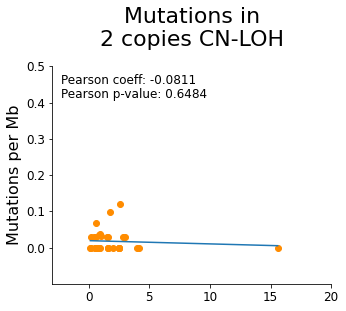

In [33]:
df2 = df1[~df1.index.isin(excluded_samples)]
x_col = 'age'
y_col = 2
y_min = -0.1
y_max = 0.4
x_min = -3
x_max = 20
c = 'darkorange'
# xlabel = 'Age at biopsy (years)'
xlabel = ''
ylabel = 'Mutations per Mb'
title = 'Mutations in\n2 copies CN-LOH'
plot_correlation(df2,x_col,y_col,x_min,x_max,y_min,y_max,c,title,xlabel,ylabel)
plt.title(title,size=22,pad=20)
plt.xticks(range(0,x_max+1,5),size=12)
plt.yticks(np.linspace(0,0.5,6),size=12)
plt.savefig('plots/correlation_before_cnloh_diagnosis.svg', bbox_inches='tight',format='svg')
plt.show()

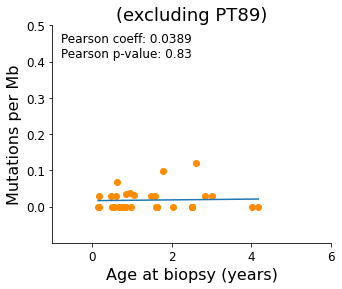

In [34]:
outliers = ['pt15_t1']
df3 = df2[~df2.index.isin(outliers)]
y_col = 2
y_min = -0.1
y_max = 0.4
x_min = -1
x_max = 6
c = 'darkorange'
xlabel = 'Age at biopsy (years)'
ylabel = 'Mutations per Mb'
# title = 'Mutations in\n2 copies CN-LOH\n(excluding PT89)'
title = '(excluding PT89)'
plot_correlation(df3,x_col,y_col,x_min,x_max,y_min,y_max,c,title,xlabel,ylabel)
plt.title(title,size=18,pad=5)
plt.xticks(range(0,x_max+1,2),size=12)
plt.yticks(np.linspace(0,0.5,6),size=12)
plt.savefig('plots/correlation_before_cnloh_diagnosis_excluding_pt89.svg', bbox_inches='tight',format='svg')
plt.show()

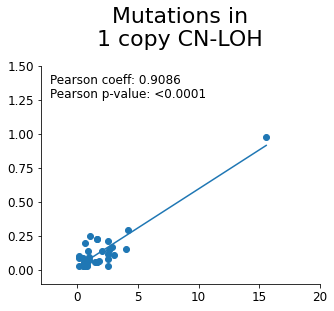

In [35]:
y_col = 1
y_min = -0.1
y_max = 1.5
x_min = -3
x_max = 20
c = '#1f77b4'
# xlabel = 'Age at biopsy (years)'
xlabel = ''
# ylabel = 'Mutations per Mb'
ylabel = ''
title = 'Mutations in\n1 copy CN-LOH'
plot_correlation(df2,x_col,y_col,x_min,x_max,y_min,y_max,c,title,xlabel,ylabel)
plt.title(title,size=22,pad=20)
plt.xticks(range(0,x_max+1,5),size=12)
plt.yticks(np.linspace(0,1.5,7),size=12)
plt.savefig('plots/correlation_after_cnloh_diagnosis.svg', bbox_inches='tight',format='svg')
plt.show()

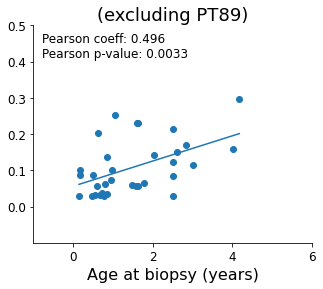

In [36]:
y_col = 1
y_min = -0.1
y_max = 0.5
x_min = -1
x_max = 6
c = '#1f77b4'
xlabel = 'Age at biopsy (years)'
# ylabel = 'Mutations per Mb'
ylabel = ''
# title = 'Mutations in\n1 copy CN-LOH\n(excluding PT89)'
title = '(excluding PT89)'
plot_correlation(df3,x_col,y_col,x_min,x_max,y_min,y_max,c,title,xlabel,ylabel)
plt.title(title,size=18,pad=5)
plt.xticks(range(0,x_max+1,2),size=12)
plt.yticks(np.linspace(0,0.5,6),size=12)
plt.savefig('plots/correlation_after_cnloh_diagnosis_excluding_pt89.svg', bbox_inches='tight',format='svg')
plt.show()

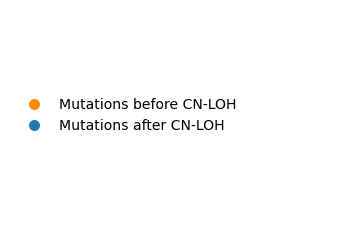

In [37]:
categories = ['Mutations before CN-LOH','Mutations after CN-LOH']
n_cats = len(categories)
labels = categories
colors_list = ['darkorange','#1f77b4']
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_list[j], markersize=12) for j in range(n_cats)]
plt.axis('off')
legend_title = ''
plt.legend(handles, labels, title=legend_title, loc='center left', ncol=1, fontsize=14, title_fontsize=15, frameon=False)
plt.savefig('plots/cnloh_mrca_relatve_timing_legend.svg', bbox_inches='tight',format='svg')